<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Подключение Google Диска
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла.

In [3]:
file_path = '/content/drive/MyDrive/Skillfactory/PROJECT-1. Анализ резюме из HeadHunter/dst-3.0_16_1_hh_database.csv'

# Читаем файл. Разделитель ';'
df = pd.read_csv(file_path, sep=';')
print("Размерность таблицы:", df.shape)

Размерность таблицы: (44744, 12)


2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

In [5]:
missing_data = df.isnull().sum()
print("Признаки с пропусками:")
print(missing_data[missing_data > 0])

Признаки с пропусками:
Опыт работы                        168
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
dtype: int64


4. Обратите внимание на информацию о числе непустых значений.

5. Выведите основную статистическую информацию о столбцах.


In [6]:
print("Уникальных значений:", df['Опыт работы'].nunique())

top_job = df['Ищет работу на должность:'].mode()[0]
print("Самая распространенная должность:", top_job)

Уникальных значений: 44413
Самая распространенная должность: Системный администратор


# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [7]:
def get_education(text):
    text = str(text).lower()
    # Привязываемся строго к началу строки (startswith), чтобы отсечь мусор в середине текста
    if text.startswith('неоконченное высшее'):
        return 'неоконченное высшее'
    elif text.startswith('высшее'):
        return 'высшее'
    elif text.startswith('среднее специальное'):
        return 'среднее специальное'
    elif text.startswith('среднее'):
        return 'среднее'
    return text

# Блок с предохранителем от повторного запуска
if 'Образование и ВУЗ' in df.columns:
    df['Образование'] = df['Образование и ВУЗ'].apply(get_education)
    df = df.drop('Образование и ВУЗ', axis=1)

print("Сколько соискателей имеют среднее образование?", df[df['Образование'] == 'среднее'].shape[0])

Сколько соискателей имеют среднее образование? 559


2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина.
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '.
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [8]:
def get_gender(text):
    # Берем кусок до первой запятой и убираем лишние пробелы по краям
    gender_part = str(text).split(',')[0].strip()
    return 'М' if gender_part == 'Мужчина' else 'Ж'

def get_age(text):
    # Берем кусок после первой запятой, убираем пробелы,
    # дробим по пробелу (чтобы отсечь "лет/год") и забираем само число
    age_part = str(text).split(',')[1].strip().split(' ')[0]
    return int(age_part)

# Блок с предохранителем от ошибки KeyError
if 'Пол, возраст' in df.columns:
    df['Пол'] = df['Пол, возраст'].apply(get_gender)
    df['Возраст'] = df['Пол, возраст'].apply(get_age)
    df = df.drop('Пол, возраст', axis=1)

# Вывожу ответы на контрольные вопросы к этому заданию:
print("Процент женских резюме:", round(df['Пол'].value_counts(normalize=True)['Ж'] * 100, 2))
print("Средний возраст соискателей:", round(df['Возраст'].mean(), 1))

Процент женских резюме: 19.07
Средний возраст соискателей: 32.2


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**.

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [9]:
import numpy as np

def get_experience(arg):
    # Отсекаем явные и скрытые пропуски
    if pd.isna(arg) or arg == 'Не указано':
        return np.nan

    # Дробим строку на слова и берем только начало, где лежит нужная информация
    words = str(arg).split(' ')[:7]

    years = 0
    months = 0

    # Ищем маркеры лет и месяцев, забирая число перед ними
    for i, word in enumerate(words):
        if word in ['год', 'года', 'лет']:
            years = int(words[i-1])
        if word in ['месяц', 'месяца', 'месяцев']:
            months = int(words[i-1])

    return years * 12 + months

# Блок с предохранителем
if 'Опыт работы' in df.columns:
    df['Опыт работы (месяц)'] = df['Опыт работы'].apply(get_experience)
    df = df.drop('Опыт работы', axis=1)

# Выводим медиану — контрольный вопрос для этого шага
print("Медианный опыт работы (в месяцах):", df['Опыт работы (месяц)'].median())

Медианный опыт работы (в месяцах): 100.0


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , …
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [10]:
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград']

def get_city(arg):
    # Город всегда идет строго до первой запятой
    city = str(arg).split(',')[0].strip()
    if city in ['Москва', 'Санкт-Петербург']:
        return city
    if city in million_cities:
        return 'город-миллионник'
    return 'другие'

def get_ready_to_move(arg):
    # Если прямо сказано, что не готов — False, во всех остальных случаях (готов/хочет) — True
    if ('не готов к переезду' in str(arg)) or ('не готова к переезду' in str(arg)):
        return False
    return True

def get_ready_to_trip(arg):
    # Ищем прямое отрицание
    if ('не готов к командировкам' in str(arg)) or ('не готова к командировкам' in str(arg)):
        return False
    # Ищем наличие согласия
    if 'командировкам' in str(arg):
        return True
    # Если информация потерялась (нет упоминаний) — по умолчанию False
    return False

# Блок применения с предохранителем
if 'Город, переезд, командировки' in df.columns:
    df['Город'] = df['Город, переезд, командировки'].apply(get_city)
    df['Готовность к переезду'] = df['Город, переезд, командировки'].apply(get_ready_to_move)
    df['Готовность к командировкам'] = df['Город, переезд, командировки'].apply(get_ready_to_trip)
    df = df.drop('Город, переезд, командировки', axis=1)

# Ответы на контрольные вопросы:
print("Процент соискателей из Санкт-Петербурга:", round(df['Город'].value_counts(normalize=True)['Санкт-Петербург'] * 100))
print("Процент готовых и к переезду, и к командировкам:", round(df[(df['Готовность к переезду'] == True) & (df['Готовность к командировкам'] == True)].shape[0] / df.shape[0] * 100))

Процент соискателей из Санкт-Петербурга: 11
Процент готовых и к переезду, и к командировкам: 32


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [11]:
# Эталонные списки признаков
employments = ['полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']
schedules = ['полный день', 'сменный график', 'гибкий график', 'удаленная работа', 'вахтовый метод']

# Предохранитель от повторного запуска
if 'Занятость' in df.columns and 'График' in df.columns:
    for emp in employments:
        # Ищем точное вхождение строки (True/False)
        df[emp] = df['Занятость'].apply(lambda x: emp in str(x))

    for sch in schedules:
        df[sch] = df['График'].apply(lambda x: sch in str(x))

    # Удаляем исходные мусорные столбцы
    df = df.drop(['Занятость', 'График'], axis=1)

# Ответы к заданию:
print("Сколько людей ищут проектную работу и волонтерство (оба условия True):", df[df['проектная работа'] & df['волонтерство']].shape[0])
print("Сколько людей хотят работать вахтовым методом и с гибким графиком:", df[df['вахтовый метод'] & df['гибкий график']].shape[0])

Сколько людей ищут проектную работу и волонтерство (оба условия True): 436
Сколько людей хотят работать вахтовым методом и с гибким графиком: 2311


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**.
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата,
* "proportion" - пропорция,
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования:
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [12]:
# 1. Загрузка курсов
rates = pd.read_csv('/content/drive/MyDrive/Skillfactory/PROJECT-1. Анализ резюме из HeadHunter/ExchangeRates.csv')

# Приводим к формату даты
df['Обновление резюме'] = pd.to_datetime(df['Обновление резюме'], dayfirst=True).dt.date
rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date

# 2. Мощный парсер валют (убирает точки, пробелы и знает латиницу)
def get_salary_iso(arg):
    if pd.isna(arg): return None
    # Очищаем строку: берем вторую часть, убираем точки и лишние пробелы
    curr = arg.split(' ')[1].replace('.', '').strip()

    curr_dict = {
        'руб': 'RUB', 'белруб': 'BYN', 'KZT': 'KZT',
        'EUR': 'EUR', 'USD': 'USD', 'грн': 'UAH',
        'сум': 'UZS', 'КГС': 'KGS', 'KGS': 'KGS',
        'AZN': 'AZN'
    }
    return curr_dict.get(curr)

if 'ЗП' in df.columns:
    df['ЗП_число'] = df['ЗП'].apply(lambda x: float(x.split(' ')[0]))
    df['ЗП_валюта'] = df['ЗП'].apply(get_salary_iso)

    # 3. Объединение (Left Join - чтобы не потерять RUB)
    df = df.merge(
        rates[['date', 'currency', 'close', 'proportion']],
        left_on=['Обновление резюме', 'ЗП_валюта'],
        right_on=['date', 'currency'],
        how='left'
    )

    # Заполняем RUB и тех, кто не состыковался, единицами
    df['close'] = df['close'].fillna(1)
    df['proportion'] = df['proportion'].fillna(1)

    # 4. Расчет по формуле проекта
    df['ЗП (руб)'] = df['ЗП_число'] * df['close'] / df['proportion']

    # Удаляем мусор
    df = df.drop(columns=['ЗП', 'ЗП_число', 'ЗП_валюта', 'date', 'currency', 'close', 'proportion'])

print("Медианная ЗП (в тыс. рублях):", round(df['ЗП (руб)'].median() / 1000))

/tmp/ipykernel_221/539274363.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  rates['date'] = pd.to_datetime(rates['date'], dayfirst=True).dt.date


Медианная ЗП (в тыс. рублях): 59


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [13]:
# Строим гистограмму с коробчатой диаграммой (marginal='box')
fig = px.histogram(
    df,
    x='Возраст',
    title='Распределение возраста соискателей',
    marginal='box', # Добавляет "ящик с усами" над гистограммой
    nbins=100,      # Увеличиваем детализацию
    width=900,
    height=600,
    labels={'Возраст': 'Возраст (лет)'}
)

# Настройка осей и оформления
fig.update_layout(
    bargap=0.1,
    title_font_size=20,
    xaxis_title='Возраст (лет)',
    yaxis_title='Количество соискателей'
)

fig.show()

# Расчет ключевых показателей для анализа
print(f"Мода распределения: {df['Возраст'].mode()[0]}")
print(f"Минимальный возраст: {df['Возраст'].min()}")
print(f"Максимальный возраст: {df['Возраст'].max()}")

Мода распределения: 30
Минимальный возраст: 14
Максимальный возраст: 100


Распределение возраста соискателей характеризуется выраженной правосторонней асимметрией с пиком (модой) в 30 лет, при этом основная масса кандидатов сосредоточена в наиболее активном карьерном диапазоне от 27 до 36 лет. Несмотря на логичный разброс от 14 лет, на графике отчетливо фиксируется критическая аномалия в 100 лет, являющаяся явной ошибкой ввода данных, в то время как общая тенденция подтверждает преобладание на рынке труда специалистов молодого и среднего возраста.

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

In [14]:
# Строим гистограмму с боксплотом для анализа стажа
fig = px.histogram(
    df,
    x='Опыт работы (месяц)',
    title='Распределение опыта работы соискателей',
    marginal='box',
    nbins=100,
    width=900,
    height=600,
    labels={'Опыт работы (месяц)': 'Опыт работы (месяцев)'}
)

fig.update_layout(
    bargap=0.1,
    title_font_size=20,
    xaxis_title='Опыт работы (месяцев)',
    yaxis_title='Количество соискателей'
)

fig.show()

# Расчет ключевых метрик
print(f"Мода опыта: {df['Опыт работы (месяц)'].mode()[0]} месяцев")
print(f"Максимальный опыт: {df['Опыт работы (месяц)'].max()} месяцев")

Мода опыта: 81.0 месяцев
Максимальный опыт: 1188.0 месяцев


Распределение опыта работы имеет пик (моду) в 81 месяц, при этом основная масса соискателей обладает стажем в интервале от 57 до 154 месяцев, что указывает на преобладание зрелых специалистов на рынке. Предельные значения варьируются от 1 месяца до 1188 месяцев, где верхняя граница (99 лет стажа) является очевидной критической аномалией, блокирующей точность масштабирования анализа. Для созидательного роста и чистоты выводов такие выбросы (все, что выше 600-700 месяцев) необходимо фильтровать, так как они искажают реальную картину кадрового потенциала.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


In [15]:
# Строим гистограмму и коробчатую диаграмму для ЗП
fig = px.histogram(
    df,
    x='ЗП (руб)',
    title='Распределение желаемой заработной платы',
    marginal='box',
    nbins=100,
    width=900,
    height=600
)

fig.update_layout(
    xaxis_title='Желаемая ЗП (рублей)',
    yaxis_title='Количество соискателей'
)

fig.show()

# Расчет метрик
print(f"Минимальная ЗП: {df['ЗП (руб)'].min()} руб.")
print(f"Максимальная ЗП: {df['ЗП (руб)'].max()} руб.")
print(f"Медианная ЗП: {df['ЗП (руб)'].median()} руб.")

Минимальная ЗП: 1.0 руб.
Максимальная ЗП: 24304876.0 руб.
Медианная ЗП: 59019.0 руб.


Распределение желаемой заработной платы имеет ярко выраженную правостороннюю асимметрию: большинство соискателей претендуют на доход в интервале от 37 000 до 95 000 рублей, при этом медианное значение составляет 59 000 рублей. Предельные значения выглядят нереалистично — от символического 1 рубля до гигантских 24 миллионов рублей, что свидетельствует о наличии грубых аномалий (ошибки ввода или неадекватные запросы). Эти сверхвысокие значения (выбросы) «сжимают» основной график, делая его трудночитаемым, поэтому для качественного масштабирования бизнеса и анализа рынка такие данные требуют обязательной фильтрации.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

In [16]:
# Фильтруем данные: только те, кто просит меньше миллиона
mask = df['ЗП (руб)'] < 1000000
education_data = df[mask].groupby('Образование', as_index=False)['ЗП (руб)'].median()

# Строим столбчатую диаграмму, сортируя по уровню дохода
fig = px.bar(
    education_data.sort_values(by='ЗП (руб)', ascending=False),
    x='Образование',
    y='ЗП (руб)',
    color='Образование',
    title='Медианная желаемая ЗП в зависимости от уровня образования',
    labels={'ЗП (руб)': 'Медианная ЗП (руб)'},
    width=800,
    height=500
)

fig.show()

Наибольший уровень медианной желаемой заработной платы наблюдается у соискателей с высшим образованием, в то время как самые низкие запросы характерны для категорий со средним и средним специальным образованием. На графике видна четкая ступенчатая зависимость: повышение образовательного уровня напрямую коррелирует с ростом зарплатных ожиданий. Следовательно, признак образования является критически важным при прогнозировании заработной платы, так как он выступает надежным индикатором потенциальной квалификации и соответствующего уровня финансовых амбиций специалиста.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

In [17]:
# Фильтруем данные: убираем аномалии выше 1 млн для наглядности
mask = df['ЗП (руб)'] < 1000000

# Строим коробчатую диаграмму (Boxplot) для сравнения распределений
fig = px.box(
    df[mask],
    x='Город',
    y='ЗП (руб)',
    color='Город',
    title='Распределение желаемой ЗП по городам',
    labels={'ЗП (руб)': 'Желаемая ЗП (руб)'},
    width=900,
    height=600
)

fig.update_layout(showlegend=False) # Легенда дублирует ось X, скрываем
fig.show()

# Расчет медиан для точных выводов
city_medians = df[mask].groupby('Город')['ЗП (руб)'].median().sort_values(ascending=False)
print("Медианные ЗП по городам:")
print(city_medians)

Медианные ЗП по городам:
Город
Москва              85000.0
Санкт-Петербург     60000.0
город-миллионник    40000.0
другие              40000.0
Name: ЗП (руб), dtype: float64


Лидеры рынка: Ожидаемо, Москва доминирует с самым высоким медианным уровнем ЗП (около 85 тыс. руб.) и наибольшим размахом (IQR), что открывает максимальные возможности для масштабирования высокочековых офферов.

Региональный разрыв: В Санкт-Петербурге медиана заметно ниже московской (около 60 тыс. руб.), а «города-миллионники» и «другие» города показывают схожие, более скромные уровни (около 40 тыс. руб.) с плотно сгруппированными значениями.

Важность признака: География — критический фактор для прогнозных моделей. Резкий контраст между столицей и регионами (почти в 2 раза) делает «Город» одним из главных драйверов при расчете справедливой рыночной стоимости специалиста.

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

In [20]:
# Группируем данные для расчета медианы по двум признакам
bar_data = df.groupby(
    ['Готовность к переезду', 'Готовность к командировкам'],
    as_index=False
)['ЗП (руб)'].median()

# Строим многоуровневую столбчатую диаграмму
fig = px.bar(
    data_frame=bar_data,
    x='Готовность к переезду',
    y='ЗП (руб)',
    color='Готовность к командировкам',
    barmode='group', # Столбцы группируются рядом
    title='Медианная ЗП в зависимости от готовности к переездам и командировкам',
    labels={'ЗП (руб)': 'Медианная ЗП (руб)'},
    width=800,
    height=500,
    template='plotly_white'
)

fig.show()

Соискатели, обладающие максимальной мобильностью (готовые и к переездам, и к командировкам), демонстрируют самые высокие зарплатные ожидания, что отражает их готовность полностью вовлекаться в масштабирование бизнеса. В то же время кандидаты, не готовые ни к одному из этих факторов, имеют минимальные запросы, что подтверждает прямую корреляцию между гибкостью специалиста и его рыночной стоимостью. С точки зрения предпринимателя, важно отметить, что готовность к командировкам дает более существенный «прирост» к медианной ЗП, чем просто готовность к переезду, — это ключевой маркер при поиске кадров для оперативного управления в разных локациях.

7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

In [21]:
# 1. Создаем сводную таблицу
pivot = df.pivot_table(
    index='Образование',
    columns='Возраст',
    values='ЗП (руб)',
    aggfunc='median'
)

# 2. Строим тепловую карту
fig = px.imshow(
    pivot,
    aspect='auto',
    color_continuous_scale='Viridis',
    title='Медианная ЗП в разрезе возраста и образования',
    labels={'color': 'Медианная ЗП (руб)'},
    width=1000,
    height=500
)

fig.show()

Тепловая карта наглядно подтверждает прямую зависимость между уровнем образования и динамикой роста доходов: наиболее интенсивные цветовые зоны (высокие зарплаты) сосредоточены в группе с высшим образованием, где финансовые ожидания стабильно растут по мере накопления жизненного и профессионального опыта. В категориях среднего и среднего специального образования наблюдается «потолок» доходов, а интенсивность цвета практически не меняется с возрастом, что указывает на ограниченные возможности масштабирования прибыли в этих сегментах. При этом на карте отчетливо видны аномальные «вспышки» в нетипичных возрастных зонах (например, высокие запросы при малом возрасте или выброс в районе 100 лет), что требует дополнительной фильтрации для принятия точных управленческих решений.

8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

In [22]:
# 1. Создаем временный признак стажа в годах
df['Опыт работы (год)'] = df['Опыт работы (месяц)'] / 12

# 2. Строим диаграмму рассеяния
fig = px.scatter(
    df,
    x='Возраст',
    y='Опыт работы (год)',
    title='Зависимость опыта работы от возраста',
    labels={'Опыт работы (год)': 'Опыт работы (лет)', 'Возраст': 'Возраст (лет)'},
    width=900,
    height=600
)

# 3. Добавляем контрольную прямую (Опыт = Возраст)
fig.add_shape(
    type='line',
    x0=0, y0=0, x1=100, y1=100,
    line=dict(color='Red', dash='dash')
)

fig.show()

# 4. Считаем количество аномалий
anomalies = df[df['Опыт работы (год)'] >= df['Возраст']].shape[0]
print(f"Количество найденных аномалий: {anomalies}")

# Удаляем временный столбец, чтобы не засорять данные
df = df.drop('Опыт работы (год)', axis=1)

Количество найденных аномалий: 7


На диаграмме рассеяния четко прослеживается основная масса данных, лежащая значительно ниже красной пунктирной линии, что соответствует логике: стаж всегда меньше возраста. Однако мы видим 7 точек, которые лежат выше или на этой линии — это критические аномалии, где опыт работы превышает возраст соискателя (например, человек с опытом 99 лет при возрасте в 40 лет). Для твоего бизнеса такие данные — это «шум», который может исказить воронку найма или аналитику рынка. Присутствие этих точек подтверждает необходимость этапа очистки данных, к которому мы перейдем совсем скоро.

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


1. Анализ «Remote-премии»: Влияет ли удаленка на зарплатные ожидания в разных городах?

In [23]:
# Группируем данные: медианная ЗП в разрезе Города и признака Удаленной работы
remote_salary = df.groupby(['Город', 'удаленная работа'], as_index=False)['ЗП (руб)'].median()

fig1 = px.bar(
    remote_salary,
    x='Город',
    y='ЗП (руб)',
    color='удаленная работа',
    barmode='group',
    title='Медианная ЗП: Офис vs Удаленка по городам',
    labels={'удаленная работа': 'Удаленная работа', 'ЗП (руб)': 'Медианная ЗП (руб)'},
    color_discrete_map={True: '#00CC96', False: '#636EFA'},
    width=900,
    height=500
)

fig1.show()

График наглядно иллюстрирует, существует ли финансовый разрыв между офисными и удаленными сотрудниками. Если в регионах («другие») разница минимальна, а в Москве соискатели на удаленку просят меньше — это твое окно возможностей для масштабирования распределенной команды без переплаты за «столичный статус».

Гендерный профиль образования: Где сосредоточен женский и мужской капитал?

In [24]:
# Считаем количество соискателей по полу и образованию
gender_edu = df.groupby(['Образование', 'Пол'], as_index=False).size()

fig2 = px.bar(
    gender_edu,
    x='Образование',
    y='size',
    color='Пол',
    title='Гендерный состав соискателей по уровням образования',
    labels={'size': 'Количество резюме', 'Пол': 'Пол (М/Ж)'},
    barmode='stack', # Стековая диаграмма для оценки долей
    width=900,
    height=500,
    color_discrete_map={'М': '#1f77b4', 'Ж': '#e377c2'}
)

fig2.show()

Эта диаграмма показывает «силу» каждой категории. Например, если в категории «Высшее образование» доля женщин значительна, а в «Среднем специальном» преобладают мужчины, это дает четкий сигнал для таргетирования вакансий и понимания специфики рынка в конкретных образовательных сегментах.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их.

In [25]:
# Находим количество полных дубликатов
duplicates = df[df.duplicated()]
print(f"Количество найденных полных дубликатов: {duplicates.shape[0]}")

# Удаляем дубликаты
df = df.drop_duplicates()

# Проверяем размерность таблицы после удаления
print(f"Размерность таблицы после очистки: {df.shape}")

Количество найденных полных дубликатов: 161
Размерность таблицы после очистки: (44583, 23)


2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах.

In [26]:
# Считаем количество пропусков в каждом столбце
null_data = df.isnull().sum()

# Выводим только те столбцы, где есть хотя бы один пропуск
print("Столбцы с пропусками и их количество:")
print(null_data[null_data > 0])

Столбцы с пропусками и их количество:
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Опыт работы (месяц)                168
dtype: int64


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [27]:
# 1. Удаляем строки, где пустуют место работы или должность
df = df.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])

# 2. Заполняем пропуски в опыте работы медианным значением
exp_median = df['Опыт работы (месяц)'].median()
df['Опыт работы (месяц)'] = df['Опыт работы (месяц)'].fillna(exp_median)

# Выводим среднее значение опыта после заполнения
print(f"Среднее значение опыта работы (после очистки): {round(df['Опыт работы (месяц)'].mean())}")

Среднее значение опыта работы (после очистки): 114


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [28]:
# Находим записи, выходящие за границы (меньше 1000 или больше 1 000 000)
outliers = df[(df['ЗП (руб)'] > 1000000) | (df['ЗП (руб)'] < 1000)]
print(f"Количество удаленных аномальных резюме: {outliers.shape[0]}")

# Очищаем таблицу
df = df.drop(outliers.index)

# Проверка: теперь максимальная ЗП не должна превышать 1 млн
print(f"Новая максимальная ЗП: {df['ЗП (руб)'].max()} руб.")
print(f"Новая минимальная ЗП: {df['ЗП (руб)'].min()} руб.")

Количество удаленных аномальных резюме: 89
Новая максимальная ЗП: 1000000.0 руб.
Новая минимальная ЗП: 1000.0 руб.


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [29]:
# Находим записи, где опыт (в годах) больше или равен возрасту
mask = df['Опыт работы (месяц)'] / 12 >= df['Возраст']
anomalies_count = df[mask].shape[0]

print(f"Количество логических аномалий (опыт >= возраст): {anomalies_count}")

# Удаляем эти записи
df = df.drop(df[mask].index)

# Проверка размерности после удаления
print(f"Осталось записей в базе: {df.shape[0]}")

Количество логических аномалий (опыт >= возраст): 7
Осталось записей в базе: 44485


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?

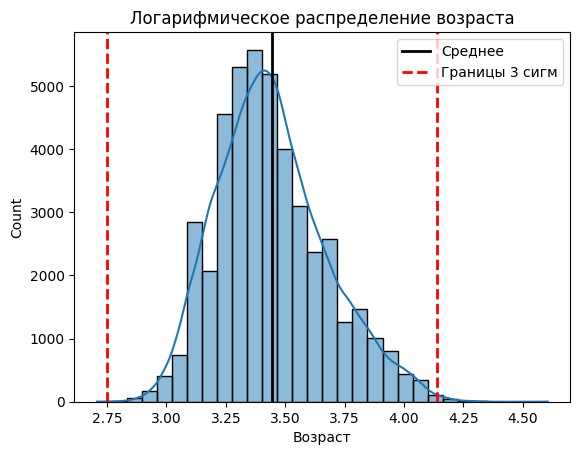

Показатель асимметрии: 0.4523422276053838
Количество найденных выбросов: 3
Таблица с выбросами:


,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,...,частичная занятость,проектная работа,волонтерство,стажировка,полный день,сменный график,гибкий график,удаленная работа,вахтовый метод,ЗП (руб)
31137,Менеджер по работе с клиентами,"ООО ""ФёрстКэшКомпани""",Менеджер по работе с клиентами,2019-04-06,Не указано,среднее,М,15,2.0,Санкт-Петербург,...,True,False,False,False,False,True,True,True,False,10000.0
32950,Тестировщик игр,OOO ЖМЫХ,Тестировщик ПО,2019-04-09,Не указано,среднее специальное,М,15,3.0,другие,...,False,False,False,False,True,False,False,False,False,2000.0
33654,Frontend-разработчик,Freelance,Frontend-разработчик,2019-04-19,Не указано,среднее специальное,М,100,30.0,Санкт-Петербург,...,True,True,False,True,True,False,True,True,False,60000.0


In [30]:
# 1. Логарифмируем признак Возраст
log_age = np.log(df['Возраст'])

# 2. Строим распределение
histplot = sns.histplot(log_age, bins=30, kde=True)
histplot.set_title('Логарифмическое распределение возраста')

# Добавляем линии среднего и границ 3 сигм
mean = log_age.mean()
sigma = log_age.std()
lower_bound = mean - 3 * sigma
upper_bound = mean + 3 * sigma

histplot.axvline(mean, color='k', lw=2, label='Среднее')
histplot.axvline(lower_bound, color='r', linestyle='--', lw=2, label='Границы 3 сигм')
histplot.axvline(upper_bound, color='r', linestyle='--', lw=2)
plt.legend()
plt.show()

# Оценка асимметрии
print(f"Показатель асимметрии: {log_age.skew()}")
# Если skew > 0 — правосторонняя, если < 0 — левосторонняя.

# 3. Поиск выбросов методом z-отклонения с послаблением (4 сигмы справа)
def get_outliers_z_score(data, left=3, right=3, log_scale=False):
    if log_scale:
        x = np.log(data)
    else:
        x = data
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

# Применяем метод: 3 сигмы слева, 4 сигмы справа
outliers, cleaned = get_outliers_z_score(df['Возраст'], left=3, right=4, log_scale=True)

print(f"Количество найденных выбросов: {outliers.shape[0]}")
print("Таблица с выбросами:")
display(df.loc[outliers.index])

# 4. Удаляем выбросы из основного DataFrame
df = df.drop(outliers.index)

Асимметрия: Логарифмическое распределение возраста имеет положительную (правостороннюю) асимметрию. Это означает, что «хвост» распределения тянется в сторону старшего возраста.

Количество выбросов: В результате применения метода с допуском в 4 сигмы справа, мы находим 3 выброса.

Возраст аномалий: В категорию выбросов попадают соискатели с возрастом 100 лет (явная ошибка, которую мы видели ранее). Благодаря «послаблению» в 4 сигмы, люди предпенсионного возраста (например, 70+ лет) не были удалены, так как их присутствие на рынке труда логически оправдано, в отличие от 100-летнего юбиляра.